In [1]:
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets

train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.CIFAR10(root='./data', train=False, transform=transforms.ToTensor(), download=True)

/home/user/rosatellif1/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Number of training samples: 50000
Number of test samples: 10000
Shape of a single image: torch.Size([3, 32, 32])
Classes in CIFAR-10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


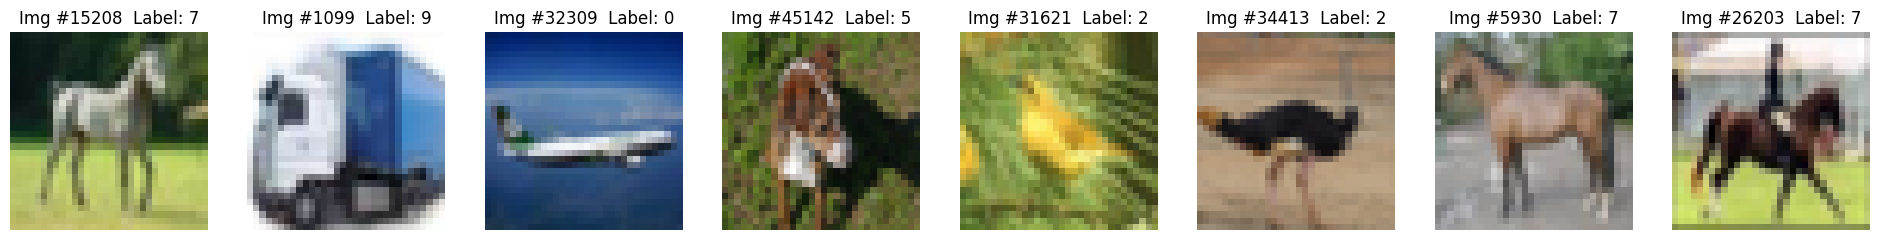

In [2]:
import matplotlib.pyplot as plt

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")

print(f"Shape of a single image: {train_dataset[0][0].shape}")

print(f"Classes in CIFAR-10: {train_dataset.classes}")

N_IMGS = 8
fig, ax = plt.subplots(1,N_IMGS)
fig.set_size_inches(3 * N_IMGS, 3)

ids = np.random.randint(low=0, high=len(train_dataset), size=N_IMGS)

for i, n in enumerate(ids):
    img = train_dataset[n][0].numpy().transpose(1, 2, 0)
    ax[i].imshow(img)
    ax[i].set_title(f"Img #{n}  Label: {train_dataset[n][1]}")
    ax[i].axis("off")
plt.show()

In [49]:
# DataLoader MLP

BATCH_SIZE = 256
SHUFFLE_TRAIN = True
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=SHUFFLE_TRAIN)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)



class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(MLP, self).__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )

    def forward(self, x):
        return self.layers(x)


def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return num_params


In [50]:
def smooth(f, K=5):
    """ Smoothing a function using a low-pass filter (mean) of size K """
    kernel = np.ones(K) / K
    f = np.concatenate([f[:int(K//2)], f, f[int(-K//2):]])  # to account for boundaries
    smooth_f = np.convolve(f, kernel, mode="same")
    smooth_f = smooth_f[K//2: -K//2]  # removing boundary-fixes
    return smooth_f

In [51]:

mplModel = MLP(input_size=32*32*3, hidden_size=1024, num_classes=len(train_dataset.classes))

In [52]:
from tqdm import tqdm

NUM_EPOCHS = 10
LR = 2e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

mplModel.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mplModel.parameters(), lr=LR)



Using device: cuda


In [53]:
loss_list = []

for epoch in range(NUM_EPOCHS):
    progress_bar = tqdm(train_loader, total=len(train_loader))
    for i, (imgs, labels) in enumerate(progress_bar):
        # using GPU
        imgs, labels = imgs.to(device), labels.to(device)
    
        # forward pass
        flattened_imgs = imgs.flatten(start_dim=1)
        preds = mplModel(flattened_imgs)
    
        # computing error
        loss = criterion(preds, labels)
        loss_list.append(loss.item())

        # removing accumulated gradients
        optimizer.zero_grad()
    
        # backprogating error to compute gradients
        loss.backward()
    
        # updating arameters
        optimizer.step()
    
        if(i % 10 == 0 or i == len(train_loader) - 1):
            progress_bar.set_description(f"Epoch {epoch + 1} Iter {i + 1}: loss {loss.item():.5f}. ")

Epoch 10 Iter 196: loss 1.13799. : 100%|██████████| 196/196 [00:04<00:00, 46.88it/s]


In [82]:
def plot_training_progress(loss_list):
    plt.style.use('seaborn-v0_8')
    fig, ax = plt.subplots(1,2)
    fig.set_size_inches(18,5)

    smooth_loss = smooth(loss_list, 31)
    ax[0].plot(loss_list, c="blue", label="Training Loss", linewidth=3, alpha=0.5)
    ax[0].plot(smooth_loss, c="red", label="Smoothed Loss", linewidth=3)
    ax[0].legend(loc="best")
    ax[0].set_xlabel("Iteration")
    ax[0].set_ylabel("CE Loss")
    ax[0].set_title("Training Progress (linearscale)")

    ax[1].plot(loss_list, c="blue", label="Training Loss", linewidth=3, alpha=0.5)
    ax[1].plot(smooth_loss, c="red", label="Smoothed Loss", linewidth=3)
    ax[1].legend(loc="best")
    ax[1].set_xlabel("Iteration")
    ax[1].set_ylabel("CE Loss")
    ax[1].set_yscale("log")
    ax[1].set_title("Training Progress (logscale)")

    plt.show()

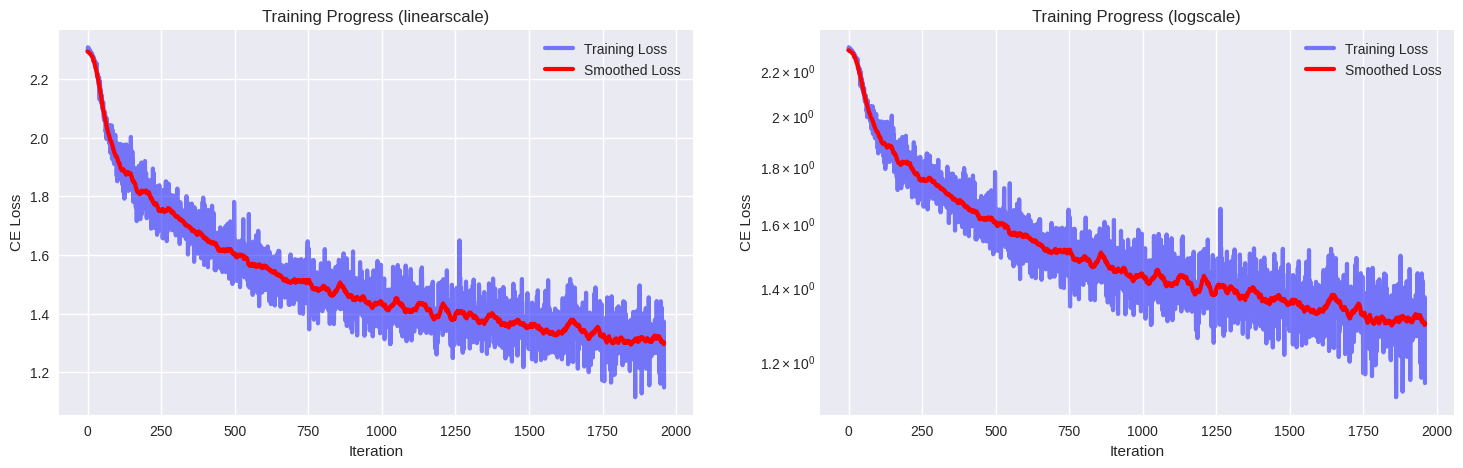

In [83]:
plot_training_progress(loss_list)

In [95]:
def evaluate_model(model, test_loader, test_dataset, device, flatten=True):
    n_correct = 0

    with torch.no_grad():
        progress_bar = tqdm(enumerate(test_loader), total=len(test_loader))
        for i, (imgs, labels) in progress_bar: 
            #everything needs to be on the same device
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            # forward pass
            if flatten:
                imgs = imgs.flatten(start_dim=1)
            preds = model(imgs)
            
            pred_labels = torch.argmax(torch.softmax(preds, dim=-1), dim=-1)
            cur_correct = len(torch.where(pred_labels == labels)[0])
            n_correct = n_correct + cur_correct

    accuracy = n_correct / len(test_dataset) * 100
    print(f"Test accuracy: {round(accuracy,2)}%")

In [96]:
evaluate_model(mplModel, test_loader, test_dataset, device)

100%|██████████| 40/40 [00:00<00:00, 48.22it/s]

Test accuracy: 47.88%


# CNN

In [ ]:
class CNN(nn.Module):
    """ 
    Varation of LeNet: a simple CNN model
    for image classification.
    """
    def __init__(self, num_classes):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=32,  kernel_size=5, stride=1, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.decoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=32 * 5 * 5, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=num_classes)
        )

        return
        
    def forward(self, x):
        """ Forward pass """
        
        x = self.encoder(x)
        x = self.decoder(x)
        # out2_flat = x.view(cur_b_size, -1)
        # y = self.fc(out2_flat)
        return x
    
def count_model_params(model):
    """ Counting the number of learnable parameters in a nn.Module """
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return num_params

In [116]:
cnn = CNN(num_classes=len(train_dataset.classes))

In [130]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LR = 3e-4
cnn = cnn.to(device)

criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.Adam(params=cnn.parameters(), lr=LR)

In [131]:
loss_list = []

for epoch in range(NUM_EPOCHS):
    progress_bar = tqdm(train_loader, total=len(train_loader))
    for i, (imgs, labels) in enumerate(progress_bar):
        # using GPU
        imgs, labels = imgs.to(device), labels.to(device)
    
        # forward pass
        preds = cnn(imgs)
    
        # computing error
        loss = criterion(preds, labels)
        loss_list.append(loss.item())

        # removing accumulated gradients
        optimizer.zero_grad()
    
        # backprogating error to compute gradients
        loss.backward()
    
        # updating arameters
        optimizer.step()
    
        if(i % 10 == 0 or i == len(train_loader) - 1):
            progress_bar.set_description(f"Epoch {epoch + 1} Iter {i + 1}: loss {loss.item():.5f}. ")

Epoch 10 Iter 196: loss 1.08778. : 100%|██████████| 196/196 [00:04<00:00, 46.42it/s]


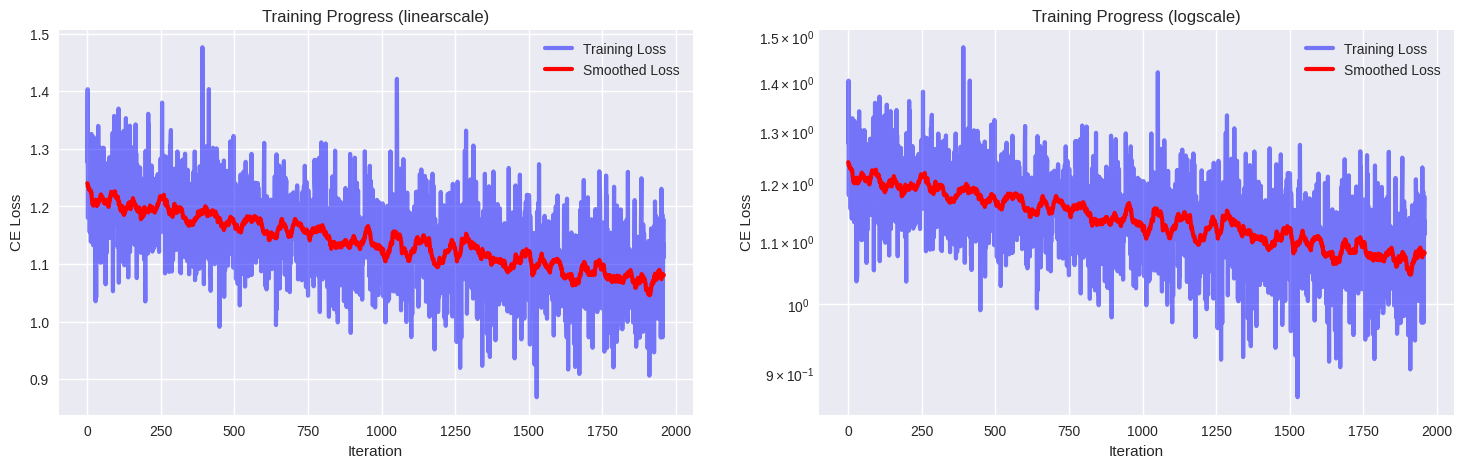

In [129]:
plot_training_progress(loss_list)

In [124]:
evaluate_model(cnn, test_loader, test_dataset, device, flatten=False)

100%|██████████| 40/40 [00:00<00:00, 49.54it/s]

Test accuracy: 55.86%
